# COVID-19 Detection from Chest X-rays using CNN

**Mini Project — End-to-End Implementation**

This notebook builds a deep-learning pipeline to classify chest X-ray images into three classes:
**COVID-19**, **Normal**, **Viral Pneumonia**.

---

## How this notebook is organized

Because the user does not have a local GPU, the work is split into two phases:

| Phase | Where to run | What happens |
|-------|--------------|--------------|
| **Phase 1 — Data Cleaning** (Sections 1–3) | **Local machine** (CPU is fine) | Load & resize images, normalize, encode labels, EDA, save preprocessed numpy arrays to disk. |
| **Phase 2 — Model Training** (Sections 4–8) | **Google Colab (GPU runtime)** | Upload the preprocessed `.npz` file, train 4 models, evaluate, handle imbalance, tune, compare. |
| **Phase 3 — Deployment** (Section 9) | **Local machine** | Streamlit web app loads the best trained model and predicts on uploaded X-rays. |

The notebook **auto-detects** the environment (Colab vs local) and runs only the relevant cells. You can run the whole notebook top-to-bottom on Colab too — it will just redo Phase 1 there. The recommended path is the split workflow above.

---

## Dataset

[Kaggle — COVID-19 Image Dataset](https://www.kaggle.com/datasets/pranavraikokte/covid19-image-dataset)

```
Covid19-dataset/
├── train/
│   ├── Covid/            (111 images)
│   ├── Normal/           (70 images)
│   └── Viral Pneumonia/  (70 images)
└── test/
    ├── Covid/            (26 images)
    ├── Normal/           (20 images)
    └── Viral Pneumonia/  (20 images)
```

## 0. Environment Setup & Configuration

The cell below detects whether we are on **Colab** or **local**, sets up paths, and creates the working directories.

- **Local path**: place the unzipped dataset at `./Covid19-dataset/` (same folder as this notebook).
- **Colab path**: download the dataset via the Kaggle API (instructions in the cell below), or upload the preprocessed `.npz` from Phase 1.

In [2]:
# --- Environment detection -------------------------------------------------
import os, sys, platform

try:
    import google.colab          # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

print(f"Running in Colab: {IN_COLAB}")
print(f"Python: {sys.version.split()[0]}   |   OS: {platform.system()}")

# --- Configuration ---------------------------------------------------------
IMG_SIZE       = 128        # 128x128. Switch to 224 for VGG16/ResNet50 in Phase 2.
CLASSES = ['Covid', 'Normal', 'Viral Pneumonia']
NUM_CLASSES    = len(CLASSES)
RANDOM_STATE   = 42

# Paths (adjust if your dataset lives elsewhere)
if IN_COLAB:
    DATA_DIR      = "/content/Covid19-dataset"
    PREPROC_PATH  = "/content/covid_xray_preprocessed.npz"
    MODELS_DIR    = "/content/models"
else:
    DATA_DIR      = "Covid19-dataset"
    PREPROC_PATH  = "covid_xray_preprocessed.npz"
    MODELS_DIR    = "models"

os.makedirs(MODELS_DIR, exist_ok=True)
print(f"DATA_DIR     = {DATA_DIR}")
print(f"PREPROC_PATH = {PREPROC_PATH}")
print(f"MODELS_DIR   = {MODELS_DIR}")

Running in Colab: True
Python: 3.12.13   |   OS: Linux
DATA_DIR     = /content/Covid19-dataset
PREPROC_PATH = /content/covid_xray_preprocessed.npz
MODELS_DIR   = /content/models


### Install dependencies

Run the next cell on **first use** in each environment. On Colab, TensorFlow / Keras / scikit-learn are pre-installed — only `keras-tuner` typically needs adding.

In [2]:
# Install only what's missing. Comment out lines you already have locally.
%pip install -q numpy pandas matplotlib seaborn scikit-learn opencv-python pillow tensorflow keras-tuner

Note: you may need to restart the kernel to use updated packages.


---
# PHASE 1 — Data Cleaning & Preparation (run locally)

We now do everything that does **not** need a GPU: loading images from disk, resizing, normalizing, encoding labels, EDA, and finally saving compact numpy arrays for Colab.

## 1. Data Loading and Exploration

### 1.1 Import libraries

In [3]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical

np.random.seed(RANDOM_STATE)

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100
print("Libraries loaded.")

Libraries loaded.


### 1.3 Load images & labels

We walk through the train/test folders, read each image with OpenCV, convert BGR→RGB, resize to `IMG_SIZE × IMG_SIZE`, and stack them into numpy arrays.

> **Why this works on CPU**: each image is small after resizing (128×128×3 = ~49KB), and the total dataset is only ~317 images. The whole load takes well under a minute on any laptop.

In [3]:
def load_split(split_name, data_dir=DATA_DIR, img_size=IMG_SIZE):
    """Load all images from one split (train/test) into (X, y, paths) arrays."""
    X, y, paths = [], [], []
    split_dir = os.path.join(data_dir, split_name)
    if not os.path.isdir(split_dir):
        raise FileNotFoundError(
            f"Could not find {split_dir}. Place the dataset there or update DATA_DIR."
        )

    for cls_name in sorted(os.listdir(split_dir)):
        cls_dir = os.path.join(split_dir, cls_name)
        if not os.path.isdir(cls_dir):
            continue
        for fname in sorted(os.listdir(cls_dir)):
            fpath = os.path.join(cls_dir, fname)
            img = cv2.imread(fpath)
            if img is None:                       # skip unreadable / corrupt files
                print(f"  [warn] skipped unreadable file: {fpath}")
                continue
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, (img_size, img_size), interpolation=cv2.INTER_AREA)
            X.append(img)
            y.append(cls_name)
            paths.append(fpath)

    return np.array(X, dtype=np.uint8), np.array(y), paths


X_train_full, y_train_full, paths_train = load_split("train")
X_test,       y_test,       paths_test  = load_split("test")

print(f"Train: X={X_train_full.shape}, y={y_train_full.shape}")
print(f"Test : X={X_test.shape}, y={y_test.shape}")
print(f"\nTrain class counts: {dict(Counter(y_train_full))}")
print(f"Test  class counts: {dict(Counter(y_test))}")

Train: X=(251, 128, 128, 3), y=(251,)
Test : X=(66, 128, 128, 3), y=(66,)

Train class counts: {np.str_('Covid'): 111, np.str_('Normal'): 70, np.str_('Viral Pneumonia'): 70}
Test  class counts: {np.str_('Covid'): 26, np.str_('Normal'): 20, np.str_('Viral Pneumonia'): 20}


### 1.4 Display sample images from each class

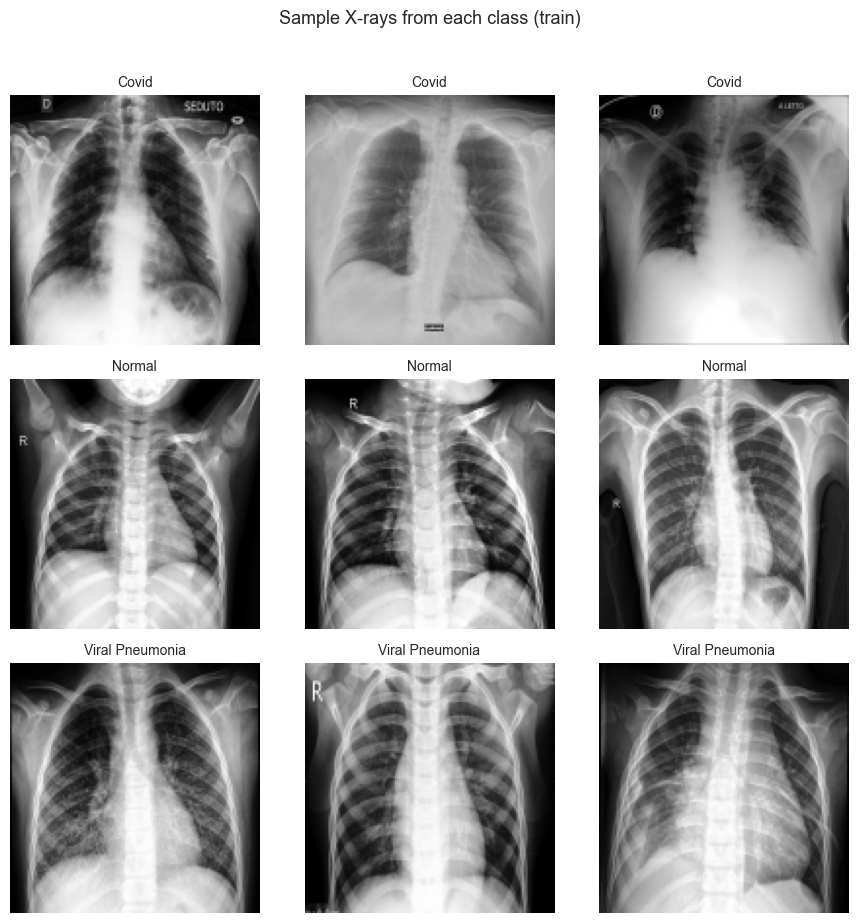

In [4]:
def show_samples(X, y, classes, n_per_class=3, title=""):
    fig, axes = plt.subplots(len(classes), n_per_class,
                             figsize=(3 * n_per_class, 3 * len(classes)))
    for i, cls in enumerate(classes):
        idxs = np.where(y == cls)[0][:n_per_class]
        for j, idx in enumerate(idxs):
            ax = axes[i, j] if len(classes) > 1 else axes[j]
            ax.imshow(X[idx])
            ax.set_title(f"{cls}", fontsize=10)
            ax.axis("off")
    plt.suptitle(title, fontsize=13, y=1.02)
    plt.tight_layout()
    plt.show()

show_samples(X_train_full, y_train_full, CLASSES,
             n_per_class=3, title="Sample X-rays from each class (train)")

## 2. Data Preprocessing

### 2.1 Normalize pixel values to [0, 1]
We keep an unnormalized `uint8` copy too — VGG16/ResNet50 in Phase 2 need their own preprocessing functions (`preprocess_input`) applied to the original 0–255 range.

In [5]:
X_train_full_norm = X_train_full.astype("float32") / 255.0
X_test_norm       = X_test.astype("float32") / 255.0
print(f"Normalized range: [{X_train_full_norm.min():.3f}, {X_train_full_norm.max():.3f}]")

Normalized range: [0.000, 1.000]


### 2.2 Encode class labels (LabelEncoder + one-hot)

In [6]:
le = LabelEncoder()
le.fit(CLASSES)                                  # fix the class order

y_train_full_enc = le.transform(y_train_full)
y_test_enc       = le.transform(y_test)

y_train_full_oh  = to_categorical(y_train_full_enc, num_classes=NUM_CLASSES)
y_test_oh        = to_categorical(y_test_enc,       num_classes=NUM_CLASSES)

print(f"Class index mapping: {dict(zip(le.classes_, le.transform(le.classes_)))}")
print(f"y_train_full_oh.shape = {y_train_full_oh.shape}")

Class index mapping: {np.str_('Covid'): np.int64(0), np.str_('Normal'): np.int64(1), np.str_('Viral Pneumonia'): np.int64(2)}
y_train_full_oh.shape = (251, 3)


### 2.3 Train / Validation split (80 / 20, stratified)

The Kaggle archive already gives us a separate `test/` folder, so the only split we do here is **train → train + val**. We keep parallel uint8 arrays so VGG16/ResNet50 in Phase 2 can apply their own `preprocess_input` to 0-255 inputs.

In [7]:
# Split BOTH the normalized float arrays AND the raw uint8 arrays consistently
# by splitting an index array first.
idx_all = np.arange(len(X_train_full_norm))

idx_tr, idx_val, y_train_oh, y_val_oh, y_train_enc, y_val_enc = train_test_split(
    idx_all, y_train_full_oh, y_train_full_enc,
    test_size=0.20,
    stratify=y_train_full_enc,
    random_state=RANDOM_STATE,
)

X_train       = X_train_full_norm[idx_tr]
X_val         = X_train_full_norm[idx_val]
X_train_uint8 = X_train_full[idx_tr]            # raw 0-255 for transfer-learning preprocess_input
X_val_uint8   = X_train_full[idx_val]

print(f"Train     : {X_train.shape} (uint8 twin: {X_train_uint8.shape})")
print(f"Validation: {X_val.shape}   (uint8 twin: {X_val_uint8.shape})")
print(f"Test      : {X_test_norm.shape}")

Train     : (200, 128, 128, 3) (uint8 twin: (200, 128, 128, 3))
Validation: (51, 128, 128, 3)   (uint8 twin: (51, 128, 128, 3))
Test      : (66, 128, 128, 3)


## 3. Exploratory Data Analysis (EDA)

### 3.1 Class distribution (train / val / test)

C:\Users\ANUJ SALWAN\AppData\Local\Temp\ipykernel_246744\505964907.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cls_names, y=cls_counts, ax=ax,
C:\Users\ANUJ SALWAN\AppData\Local\Temp\ipykernel_246744\505964907.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cls_names, y=cls_counts, ax=ax,
C:\Users\ANUJ SALWAN\AppData\Local\Temp\ipykernel_246744\505964907.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cls_names, y=cls_counts, ax=ax,


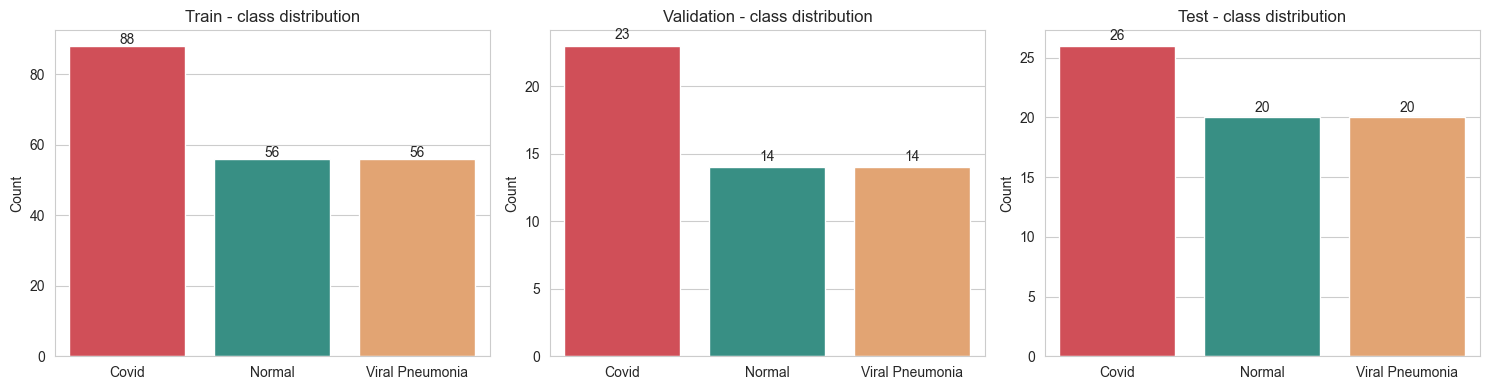

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (labels, name) in zip(axes, [
    (y_train_enc, "Train"),
    (y_val_enc,   "Validation"),
    (y_test_enc,  "Test"),
]):
    counts = Counter(labels)
    cls_names  = [CLASSES[i] for i in sorted(counts.keys())]
    cls_counts = [counts[i] for i in sorted(counts.keys())]
    sns.barplot(x=cls_names, y=cls_counts, ax=ax,
                palette=["#e63946", "#2a9d8f", "#f4a261"])
    ax.set_title(f"{name} - class distribution")
    ax.set_ylabel("Count")
    for i, v in enumerate(cls_counts):
        ax.text(i, v + 0.5, str(v), ha="center", fontsize=10)
plt.tight_layout()
plt.show()

**Observation**: The training set is **imbalanced** — *Covid* has ~58% more samples than *Normal* / *Viral Pneumonia*. We'll handle this in Section 6 with class weights + augmentation.

### 3.2 Pixel-intensity distribution by class

Looking at intensity histograms can reveal whether the network has any easy visual shortcuts (e.g. one class systematically darker).

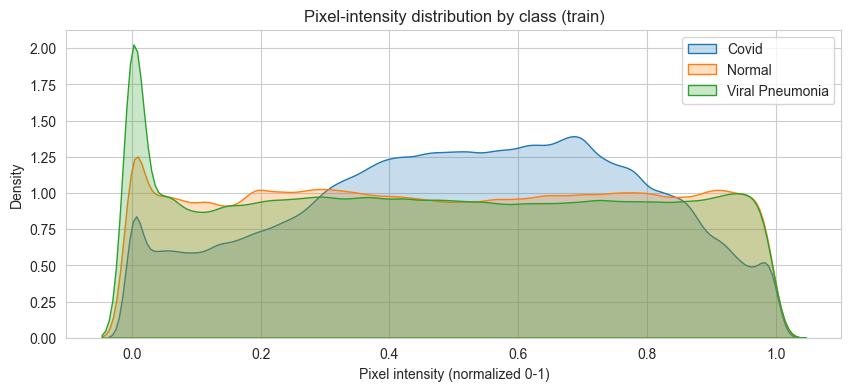

In [9]:
fig, ax = plt.subplots(figsize=(10, 4))
for cls_idx, cls in enumerate(CLASSES):
    mask = y_train_enc == cls_idx
    pixels = X_train[mask].ravel()
    sns.kdeplot(pixels, ax=ax, label=cls, fill=True, alpha=0.25)
ax.set_xlabel("Pixel intensity (normalized 0-1)")
ax.set_ylabel("Density")
ax.set_title("Pixel-intensity distribution by class (train)")
ax.legend()
plt.show()

### 3.3 Save the preprocessed data for Colab

Single `.npz` file containing every array we need. Upload it to Colab Drive or directly into the Colab session for Phase 2.

In [10]:
np.savez_compressed(
    PREPROC_PATH,
    X_train       = X_train,       X_val       = X_val,         X_test       = X_test_norm,
    X_train_uint8 = X_train_uint8, X_val_uint8 = X_val_uint8,   X_test_uint8 = X_test,
    y_train_oh    = y_train_oh,    y_val_oh    = y_val_oh,      y_test_oh    = y_test_oh,
    y_train_enc   = y_train_enc,   y_val_enc   = y_val_enc,     y_test_enc   = y_test_enc,
    classes       = np.array(CLASSES),
)

size_mb = os.path.getsize(PREPROC_PATH) / 1024 / 1024
print(f"Saved -> {PREPROC_PATH}  ({size_mb:.1f} MB)")
print("==> Upload this file to Colab for Phase 2.")

Saved -> covid_xray_preprocessed.npz  (12.9 MB)
==> Upload this file to Colab for Phase 2.


---
# PHASE 2 — Model Training (run on Google Colab with GPU)

> **How to run this phase**
> 1. Open this notebook in [Google Colab](https://colab.research.google.com/) (`File → Upload notebook`).
> 2. **Runtime → Change runtime type → Hardware accelerator: GPU (T4)**.
> 3. Upload the `covid_xray_preprocessed.npz` file you saved in Phase 1 (use the Colab file sidebar, or run the upload cell below).
> 4. Run all cells from Section 4 onwards.

If you already have a GPU locally, this section works just as well there — paths are auto-configured at the top of the notebook.

## 4. Load Preprocessed Data + Build CNN Models

In [4]:
from google.colab import drive
drive.mount('/content/drive')

PREPROC_PATH = "/content/drive/MyDrive/Data_Science/covid_xray_preprocessed.npz"
import os

if not os.path.exists(PREPROC_PATH):
    raise FileNotFoundError(
        f"Could not find {PREPROC_PATH}. "
        f"Make sure covid_xray_preprocessed.npz is in the working directory: {os.getcwd()}"
    )

data = np.load(PREPROC_PATH, allow_pickle=True)

X_train,       X_val,       X_test       = data["X_train"],       data["X_val"],       data["X_test"]
X_train_uint8, X_val_uint8, X_test_uint8 = data["X_train_uint8"], data["X_val_uint8"], data["X_test_uint8"]
y_train_oh,    y_val_oh,    y_test_oh    = data["y_train_oh"],    data["y_val_oh"],    data["y_test_oh"]
y_train_enc,   y_val_enc,   y_test_enc   = data["y_train_enc"],   data["y_val_enc"],   data["y_test_enc"]

CLASSES     = list(data["classes"])
NUM_CLASSES = len(CLASSES)

print(f"Train: {X_train.shape}   Val: {X_val.shape}   Test: {X_test.shape}")
print(f"Classes: {CLASSES}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Train: (200, 128, 128, 3)   Val: (51, 128, 128, 3)   Test: (66, 128, 128, 3)
Classes: [np.str_('Covid'), np.str_('Normal'), np.str_('Viral Pneumonia')]


In [34]:
# --- Confirm GPU is available --------------------------------------------
import tensorflow as tf
tf.random.set_seed(RANDOM_STATE)
print("TensorFlow version:", tf.__version__)
gpus = tf.config.list_physical_devices("GPU")
print("GPUs detected:", gpus if gpus else "No GPU - training will be slow.")

TensorFlow version: 2.20.0
GPUs detected: No GPU - training will be slow.


### 4.1 Common training utilities

In [5]:
from tensorflow.keras import layers, models, callbacks, optimizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16, ResNet50
from tensorflow.keras.applications.vgg16    import preprocess_input as vgg_pre
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_pre
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, accuracy_score, f1_score)
from sklearn.utils.class_weight import compute_class_weight

INPUT_SHAPE = X_train.shape[1:]                # (128, 128, 3)
print("Input shape:", INPUT_SHAPE)


def get_callbacks(model_name, patience=8):
    """Standard callbacks for every training run."""
    return [
        callbacks.EarlyStopping(monitor="val_loss", patience=patience,
                                restore_best_weights=True, verbose=1),
        callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5,
                                    patience=3, min_lr=1e-6, verbose=1),
        callbacks.ModelCheckpoint(os.path.join(MODELS_DIR, f"{model_name}.keras"),
                                  monitor="val_accuracy", save_best_only=True, verbose=0),
    ]


def plot_history(history, title=""):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(history.history["accuracy"],     label="train")
    axes[0].plot(history.history["val_accuracy"], label="val")
    axes[0].set_title(f"{title} - Accuracy"); axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Accuracy"); axes[0].legend(); axes[0].grid(alpha=0.3)

    axes[1].plot(history.history["loss"],     label="train")
    axes[1].plot(history.history["val_loss"], label="val")
    axes[1].set_title(f"{title} - Loss"); axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Loss"); axes[1].legend(); axes[1].grid(alpha=0.3)
    plt.tight_layout(); plt.show()

Input shape: (128, 128, 3)


### 4.2 Model 1 — Basic CNN

Smallest model the problem statement asks for: `Conv2D → MaxPool → Flatten → Dense`.

In [6]:
def build_basic_cnn(input_shape=INPUT_SHAPE, num_classes=NUM_CLASSES):
    model = models.Sequential([
        layers.Input(shape=input_shape),
        layers.Conv2D(32, (3, 3), activation="relu"),
        layers.MaxPooling2D(2, 2),
        layers.Flatten(),
        layers.Dense(64, activation="relu"),
        layers.Dense(num_classes, activation="softmax"),
    ], name="basic_cnn")
    model.compile(optimizer="adam",
                  loss="categorical_crossentropy",
                  metrics=["accuracy"])
    return model

basic_cnn = build_basic_cnn()
basic_cnn.summary()

Model: "basic_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 127008)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     8,128,576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,129,667 (31.01 MB)

 Trainable params: 8,129,667 (31.01 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/25
13/13 - 5s - 402ms/step - accuracy: 0.6500 - loss: 1.3054 - val_accuracy: 0.8627 - val_loss: 0.3272 - learning_rate: 0.0010
Epoch 2/25
13/13 - 5s - 404ms/step - accuracy: 0.9350 - loss: 0.2353 - val_accuracy: 0.9020 - val_loss: 0.2599 - learning_rate: 0.0010
Epoch 3/25
13/13 - 8s - 602ms/step - accuracy: 0.9650 - loss: 0.1498 - val_accuracy: 0.8235 - val_loss: 0.2883 - learning_rate: 0.0010
Epoch 4/25
13/13 - 7s - 528ms/step - accuracy: 0.9700 - loss: 0.0948 - val_accuracy: 0.8627 - val_loss: 0.2662 - learning_rate: 0.0010
Epoch 5/25
13/13 - 3s - 268ms/step - accuracy: 0.9950 - loss: 0.0446 - val_accuracy: 0.9216 - val_loss: 0.1787 - learning_rate: 0.0010
Epoch 6/25
13/13 - 3s - 266ms/step - accuracy: 1.0000 - loss: 0.0190 - val_accuracy: 0.9412 - val_loss: 0.1673 - learning_rate: 0.0010
Epoch 7/25
13/13 - 5s - 402ms/step - accuracy: 1.0000 - loss: 0.0106 - val_accuracy: 0.9412 - val_loss: 0.1826 - learning_rate: 0.0010
Epoch 8/25
13/13 - 4s - 341ms/step - accuracy: 1.0000 -

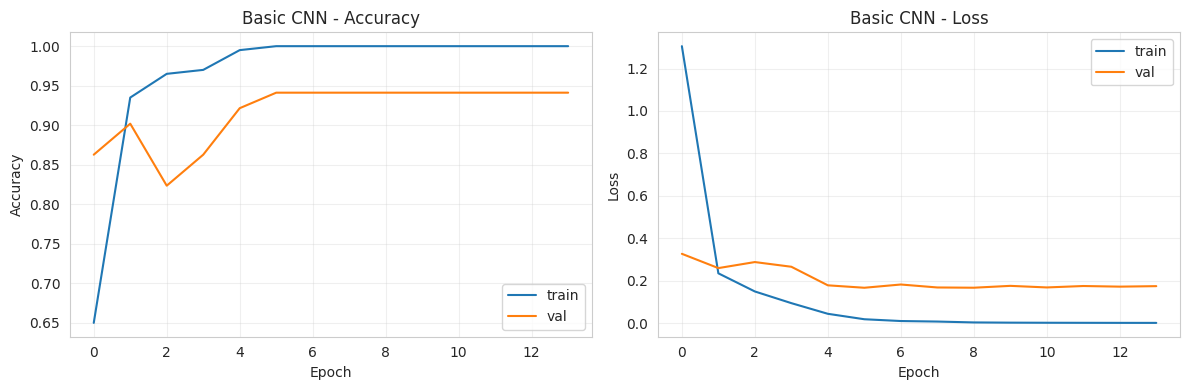

In [7]:
hist_basic = basic_cnn.fit(
    X_train, y_train_oh,
    validation_data=(X_val, y_val_oh),
    epochs=25,
    batch_size=16,
    callbacks=get_callbacks("basic_cnn"),
    verbose=2,
)
plot_history(hist_basic, "Basic CNN")

### 4.3 Model 2 — Deeper CNN (with Dropout + BatchNorm)

A more reasonable hand-rolled architecture: three Conv blocks with batch-norm and dropout to fight overfitting on this small dataset.

In [8]:
def build_deep_cnn(input_shape=INPUT_SHAPE, num_classes=NUM_CLASSES):
    model = models.Sequential([
        layers.Input(shape=input_shape),

        layers.Conv2D(32, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2),

        layers.Conv2D(64, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2),

        layers.Conv2D(128, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2),

        layers.GlobalAveragePooling2D(),
        layers.Dense(128, activation="relu"),
        layers.Dropout(0.4),
        layers.Dense(num_classes, activation="softmax"),
    ], name="deep_cnn")
    model.compile(optimizer=optimizers.Adam(1e-3),
                  loss="categorical_crossentropy",
                  metrics=["accuracy"])
    return model

deep_cnn = build_deep_cnn()
deep_cnn.summary()

Model: "deep_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 111,043 (433.76 KB)

 Trainable params: 110,595 (432.01 KB)

 Non-trainable params: 448 (1.75 KB)

Epoch 1/35
13/13 - 24s - 2s/step - accuracy: 0.6100 - loss: 0.8437 - val_accuracy: 0.4510 - val_loss: 1.0791 - learning_rate: 0.0010
Epoch 2/35
13/13 - 10s - 797ms/step - accuracy: 0.6700 - loss: 0.6732 - val_accuracy: 0.4510 - val_loss: 1.0751 - learning_rate: 0.0010
Epoch 3/35
13/13 - 12s - 920ms/step - accuracy: 0.7850 - loss: 0.5603 - val_accuracy: 0.4510 - val_loss: 1.0807 - learning_rate: 0.0010
Epoch 4/35
13/13 - 12s - 901ms/step - accuracy: 0.8250 - loss: 0.4936 - val_accuracy: 0.4510 - val_loss: 1.2618 - learning_rate: 0.0010
Epoch 5/35

Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
13/13 - 12s - 898ms/step - accuracy: 0.8350 - loss: 0.4016 - val_accuracy: 0.4510 - val_loss: 1.3584 - learning_rate: 0.0010
Epoch 6/35
13/13 - 10s - 781ms/step - accuracy: 0.8700 - loss: 0.3642 - val_accuracy: 0.4510 - val_loss: 1.6997 - learning_rate: 5.0000e-04
Epoch 7/35
13/13 - 12s - 893ms/step - accuracy: 0.8650 - loss: 0.3531 - val_accuracy: 0.4510 - val_loss: 2

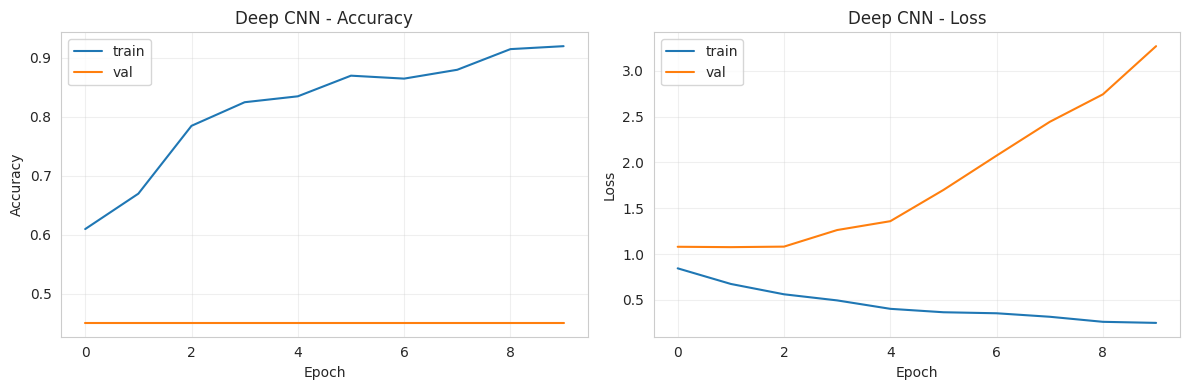

In [9]:
hist_deep = deep_cnn.fit(
    X_train, y_train_oh,
    validation_data=(X_val, y_val_oh),
    epochs=35,
    batch_size=16,
    callbacks=get_callbacks("deep_cnn"),
    verbose=2,
)
plot_history(hist_deep, "Deep CNN")

### 4.4 Model 3 — VGG16 (Transfer Learning)

We freeze the convolutional base of VGG16 (pretrained on ImageNet), add a small classification head, and fine-tune the last 4 layers.
Inputs use VGG16's own `preprocess_input` (mean-subtraction on a 0–255 image), so we work from the `uint8` arrays.

In [10]:
# VGG16 inputs (0-255 -> VGG mean-subtraction)
X_train_vgg = vgg_pre(X_train_uint8.astype("float32"))
X_val_vgg   = vgg_pre(X_val_uint8.astype("float32"))
X_test_vgg  = vgg_pre(X_test_uint8.astype("float32"))
print("VGG inputs ready:", X_train_vgg.shape, X_val_vgg.shape, X_test_vgg.shape)

VGG inputs ready: (200, 128, 128, 3) (51, 128, 128, 3) (66, 128, 128, 3)


In [11]:
def build_vgg16(input_shape=INPUT_SHAPE, num_classes=NUM_CLASSES, fine_tune_at=None):
    base = VGG16(weights="imagenet", include_top=False, input_shape=input_shape)
    base.trainable = False                          # freeze entire base first

    if fine_tune_at is not None:                    # optional: unfreeze top N layers
        for layer in base.layers[-fine_tune_at:]:
            layer.trainable = True

    model = models.Sequential([
        base,
        layers.GlobalAveragePooling2D(),
        layers.Dense(128, activation="relu"),
        layers.Dropout(0.4),
        layers.Dense(num_classes, activation="softmax"),
    ], name="vgg16_transfer")
    model.compile(optimizer=optimizers.Adam(1e-4),
                  loss="categorical_crossentropy",
                  metrics=["accuracy"])
    return model

vgg_model = build_vgg16(fine_tune_at=4)             # unfreeze last 4 layers
vgg_model.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


Model: "vgg16_transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 4, 4, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,780,739 (56.38 MB)

 Trainable params: 7,145,475 (27.26 MB)

 Non-trainable params: 7,635,264 (29.13 MB)

Epoch 1/25
13/13 - 73s - 6s/step - accuracy: 0.6000 - loss: 2.1215 - val_accuracy: 0.8431 - val_loss: 0.3697 - learning_rate: 1.0000e-04
Epoch 2/25
13/13 - 61s - 5s/step - accuracy: 0.8500 - loss: 0.4015 - val_accuracy: 0.9608 - val_loss: 0.1899 - learning_rate: 1.0000e-04
Epoch 3/25
13/13 - 90s - 7s/step - accuracy: 0.9250 - loss: 0.1779 - val_accuracy: 0.9020 - val_loss: 0.3295 - learning_rate: 1.0000e-04
Epoch 4/25
13/13 - 72s - 6s/step - accuracy: 0.9550 - loss: 0.1304 - val_accuracy: 0.9412 - val_loss: 0.1409 - learning_rate: 1.0000e-04
Epoch 5/25
13/13 - 82s - 6s/step - accuracy: 0.9900 - loss: 0.0328 - val_accuracy: 0.9412 - val_loss: 0.2083 - learning_rate: 1.0000e-04
Epoch 6/25
13/13 - 82s - 6s/step - accuracy: 0.9800 - loss: 0.0346 - val_accuracy: 0.9412 - val_loss: 0.2825 - learning_rate: 1.0000e-04
Epoch 7/25

Epoch 7: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
13/13 - 89s - 7s/step - accuracy: 0.9950 - loss: 0.0192 - val_accuracy: 0.9216 - val_loss:

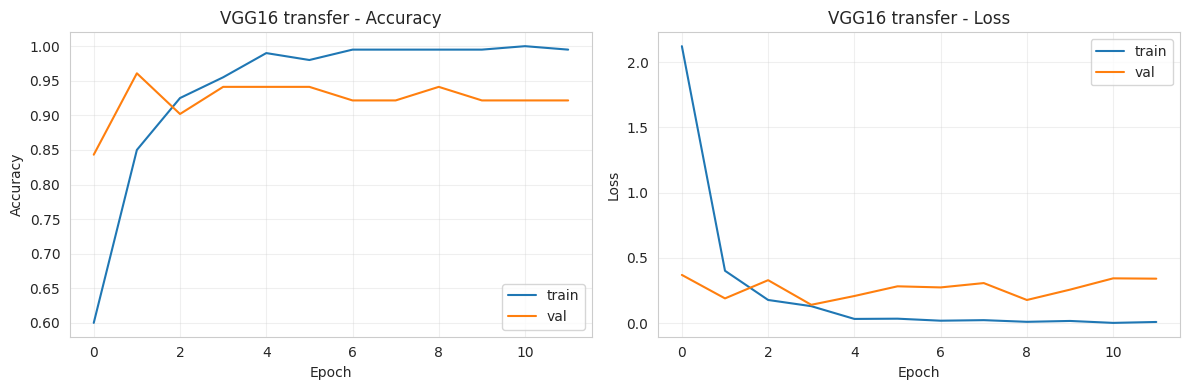

In [12]:
hist_vgg = vgg_model.fit(
    X_train_vgg, y_train_oh,
    validation_data=(X_val_vgg, y_val_oh),
    epochs=25,
    batch_size=16,
    callbacks=get_callbacks("vgg16"),
    verbose=2,
)
plot_history(hist_vgg, "VGG16 transfer")

### 4.5 Model 4 — ResNet50 + Data Augmentation

Final model from the problem statement: pretrained ResNet50 with `ImageDataGenerator` augmentation to combat the small dataset size, plus class weights for the Covid-heavy imbalance.

In [13]:
# ResNet50 inputs
X_train_rn = resnet_pre(X_train_uint8.astype("float32"))
X_val_rn   = resnet_pre(X_val_uint8.astype("float32"))
X_test_rn  = resnet_pre(X_test_uint8.astype("float32"))

# Data augmentation generator (only on training data)
aug = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.10,
    height_shift_range=0.10,
    zoom_range=0.10,
    horizontal_flip=True,
    fill_mode="nearest",
)
aug.fit(X_train_rn)
train_flow = aug.flow(X_train_rn, y_train_oh, batch_size=16, seed=RANDOM_STATE)
print("Augmentation generator ready.")

Augmentation generator ready.


In [14]:
def build_resnet50(input_shape=INPUT_SHAPE, num_classes=NUM_CLASSES, fine_tune_at=10):
    base = ResNet50(weights="imagenet", include_top=False, input_shape=input_shape)
    base.trainable = False
    for layer in base.layers[-fine_tune_at:]:
        layer.trainable = True

    model = models.Sequential([
        base,
        layers.GlobalAveragePooling2D(),
        layers.Dense(128, activation="relu"),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation="softmax"),
    ], name="resnet50_transfer")
    model.compile(optimizer=optimizers.Adam(1e-4),
                  loss="categorical_crossentropy",
                  metrics=["accuracy"])
    return model

resnet_model = build_resnet50(fine_tune_at=10)
resnet_model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


Model: "resnet50_transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 4, 4, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,850,371 (90.98 MB)

 Trainable params: 4,728,323 (18.04 MB)

 Non-trainable params: 19,122,048 (72.94 MB)

In [15]:
# Class weights to handle the Covid-heavy imbalance
cw = compute_class_weight(class_weight="balanced",
                          classes=np.arange(NUM_CLASSES),
                          y=y_train_enc)
class_weights = dict(enumerate(cw))
print("Class weights:", class_weights)

Class weights: {0: np.float64(0.7575757575757576), 1: np.float64(1.1904761904761905), 2: np.float64(1.1904761904761905)}


Epoch 1/30
12/12 - 36s - 3s/step - accuracy: 0.4348 - loss: 1.5191 - val_accuracy: 0.7843 - val_loss: 0.6158 - learning_rate: 1.0000e-04
Epoch 2/30


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


12/12 - 5s - 429ms/step - accuracy: 0.6250 - loss: 0.8545 - val_accuracy: 0.8039 - val_loss: 0.5976 - learning_rate: 1.0000e-04
Epoch 3/30
12/12 - 30s - 3s/step - accuracy: 0.7446 - loss: 0.6648 - val_accuracy: 0.8627 - val_loss: 0.5922 - learning_rate: 1.0000e-04
Epoch 4/30
12/12 - 6s - 471ms/step - accuracy: 0.8750 - loss: 0.6089 - val_accuracy: 0.8627 - val_loss: 0.5853 - learning_rate: 1.0000e-04
Epoch 5/30
12/12 - 21s - 2s/step - accuracy: 0.8261 - loss: 0.4693 - val_accuracy: 0.9216 - val_loss: 0.5458 - learning_rate: 1.0000e-04
Epoch 6/30
12/12 - 4s - 319ms/step - accuracy: 0.8750 - loss: 0.2185 - val_accuracy: 0.9216 - val_loss: 0.5457 - learning_rate: 1.0000e-04
Epoch 7/30
12/12 - 18s - 2s/step - accuracy: 0.8641 - loss: 0.3501 - val_accuracy: 0.9216 - val_loss: 0.5120 - learning_rate: 1.0000e-04
Epoch 8/30
12/12 - 5s - 414ms/step - accuracy: 0.8750 - loss: 0.3604 - val_accuracy: 0.9216 - val_loss: 0.5148 - learning_rate: 1.0000e-04
Epoch 9/30
12/12 - 20s - 2s/step - accuracy:

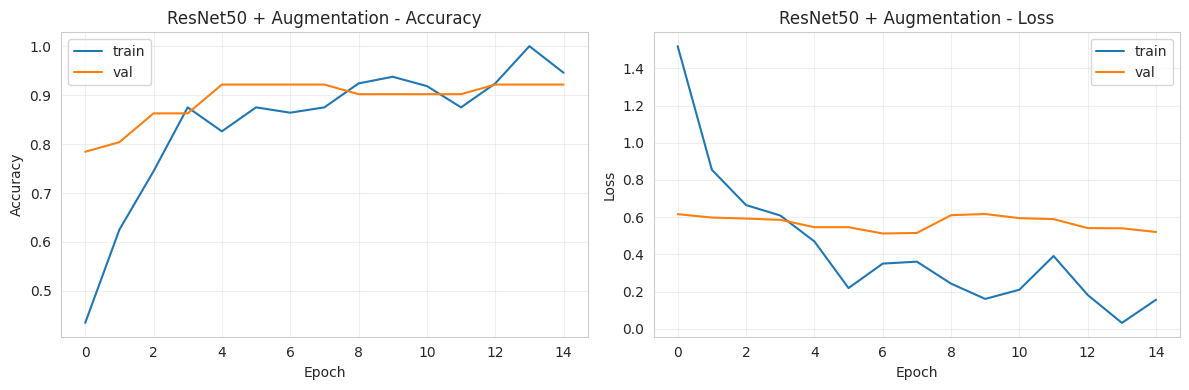

In [16]:
steps = max(1, len(X_train_rn) // 16)
hist_resnet = resnet_model.fit(
    train_flow,
    steps_per_epoch=steps,
    validation_data=(X_val_rn, y_val_oh),
    epochs=30,
    class_weight=class_weights,
    callbacks=get_callbacks("resnet50"),
    verbose=2,
)
plot_history(hist_resnet, "ResNet50 + Augmentation")

## 5. Model Evaluation

For every trained model we compute:
- Test-set accuracy
- Confusion matrix
- Classification report (precision / recall / F1)
- ROC-AUC (one-vs-rest, macro-averaged)
- Trainable-parameter count
- Overfitting check (best-train vs best-val accuracy gap)


------ Basic CNN ------
Test accuracy   : 0.8485
Macro F1        : 0.8375
Macro ROC-AUC   : 0.9604
Train acc (best): 1.0000   Val acc (best): 0.9412   Gap: +0.0588   Overfitting: N
Trainable params: 8,129,667

Classification report:
                 precision    recall  f1-score   support

          Covid       0.93      0.96      0.94        26
         Normal       0.80      0.80      0.80        20
Viral Pneumonia       0.79      0.75      0.77        20

       accuracy                           0.85        66
      macro avg       0.84      0.84      0.84        66
   weighted avg       0.85      0.85      0.85        66



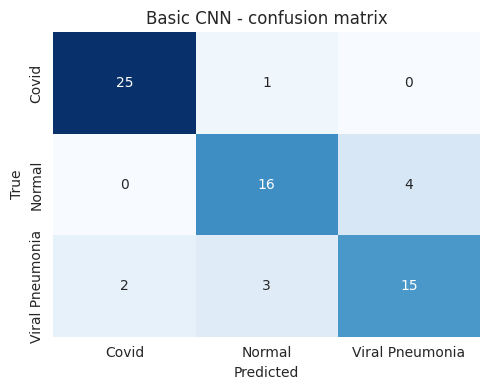


------ Deep CNN ------
Test accuracy   : 0.3939
Macro F1        : 0.1884
Macro ROC-AUC   : 0.5864
Train acc (best): 0.9200   Val acc (best): 0.4510   Gap: +0.4690   Overfitting: Y
Trainable params: 110,595

Classification report:
                 precision    recall  f1-score   support

          Covid       0.39      1.00      0.57        26
         Normal       0.00      0.00      0.00        20
Viral Pneumonia       0.00      0.00      0.00        20

       accuracy                           0.39        66
      macro avg       0.13      0.33      0.19        66
   weighted avg       0.16      0.39      0.22        66



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


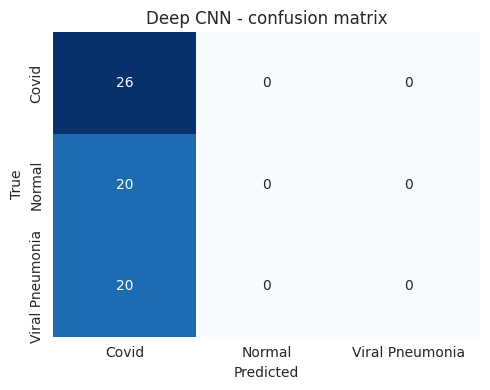


------ VGG16 ------
Test accuracy   : 0.9242
Macro F1        : 0.9153
Macro ROC-AUC   : 1.0000
Train acc (best): 1.0000   Val acc (best): 0.9608   Gap: +0.0392   Overfitting: N
Trainable params: 7,145,475

Classification report:
                 precision    recall  f1-score   support

          Covid       1.00      1.00      1.00        26
         Normal       1.00      0.75      0.86        20
Viral Pneumonia       0.80      1.00      0.89        20

       accuracy                           0.92        66
      macro avg       0.93      0.92      0.92        66
   weighted avg       0.94      0.92      0.92        66



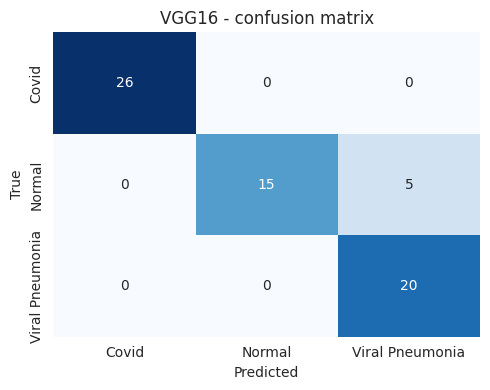


------ ResNet50 + Aug ------
Test accuracy   : 0.8182
Macro F1        : 0.8131
Macro ROC-AUC   : 0.9428
Train acc (best): 1.0000   Val acc (best): 0.9216   Gap: +0.0784   Overfitting: N
Trainable params: 4,728,323

Classification report:
                 precision    recall  f1-score   support

          Covid       1.00      0.85      0.92        26
         Normal       0.67      0.90      0.77        20
Viral Pneumonia       0.82      0.70      0.76        20

       accuracy                           0.82        66
      macro avg       0.83      0.82      0.81        66
   weighted avg       0.85      0.82      0.82        66



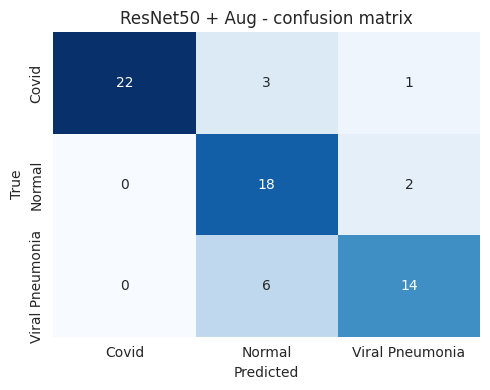

In [17]:
def evaluate_model(model, X_eval, y_eval_oh, y_eval_enc, history, title):
    """Run all evaluation steps for one trained model. Returns a dict of metrics."""
    # Predictions
    y_prob = model.predict(X_eval, verbose=0)
    y_pred = np.argmax(y_prob, axis=1)

    # Core metrics
    acc        = accuracy_score(y_eval_enc, y_pred)
    f1_macro   = f1_score(y_eval_enc, y_pred, average="macro")
    try:
        roc_auc = roc_auc_score(y_eval_oh, y_prob, multi_class="ovr", average="macro")
    except ValueError:
        roc_auc = float("nan")

    # Overfitting gap
    train_acc = max(history.history["accuracy"])
    val_acc   = max(history.history["val_accuracy"])
    overfit_gap = train_acc - val_acc
    overfitting = "Y" if overfit_gap > 0.10 else "N"

    # Trainable params
    trainable = int(sum([np.prod(v.shape) for v in model.trainable_weights]))

    # Display
    print(f"\n------ {title} ------")
    print(f"Test accuracy   : {acc:.4f}")
    print(f"Macro F1        : {f1_macro:.4f}")
    print(f"Macro ROC-AUC   : {roc_auc:.4f}")
    print(f"Train acc (best): {train_acc:.4f}   Val acc (best): {val_acc:.4f}"
          f"   Gap: {overfit_gap:+.4f}   Overfitting: {overfitting}")
    print(f"Trainable params: {trainable:,}")
    print("\nClassification report:")
    print(classification_report(y_eval_enc, y_pred, target_names=CLASSES))

    # Confusion matrix plot
    cm = confusion_matrix(y_eval_enc, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=CLASSES, yticklabels=CLASSES, cbar=False)
    plt.title(f"{title} - confusion matrix"); plt.xlabel("Predicted"); plt.ylabel("True")
    plt.tight_layout(); plt.show()

    return {
        "model":       title,
        "train_acc":   round(train_acc, 4),
        "val_acc":     round(val_acc, 4),
        "test_acc":    round(acc, 4),
        "f1_macro":    round(f1_macro, 4),
        "roc_auc":     round(roc_auc, 4),
        "overfitting": overfitting,
        "trainable":   trainable,
    }

results = []
results.append(evaluate_model(basic_cnn,    X_test,     y_test_oh, y_test_enc, hist_basic,  "Basic CNN"))
results.append(evaluate_model(deep_cnn,     X_test,     y_test_oh, y_test_enc, hist_deep,   "Deep CNN"))
results.append(evaluate_model(vgg_model,    X_test_vgg, y_test_oh, y_test_enc, hist_vgg,    "VGG16"))
results.append(evaluate_model(resnet_model, X_test_rn,  y_test_oh, y_test_enc, hist_resnet, "ResNet50 + Aug"))

## 6. Handling Class Imbalance

We already saw in Section 3.1 that the training set leans Covid-heavy (111 / 70 / 70). Two complementary strategies:

1. **Class weights in `model.fit()`** — already applied to ResNet50 above.
2. **Oversampling via augmentation** — `ImageDataGenerator` rotation / shift / zoom / flip effectively gives the minority classes more "synthetic" exposures.

Below we re-train the Deep CNN with **class weights enabled** so we can see the direct effect on a like-for-like architecture.

Epoch 1/35
13/13 - 15s - 1s/step - accuracy: 0.5850 - loss: 0.8642 - val_accuracy: 0.3529 - val_loss: 1.0866 - learning_rate: 0.0010
Epoch 2/35
13/13 - 11s - 818ms/step - accuracy: 0.7950 - loss: 0.6126 - val_accuracy: 0.4510 - val_loss: 1.0655 - learning_rate: 0.0010
Epoch 3/35
13/13 - 22s - 2s/step - accuracy: 0.8050 - loss: 0.5148 - val_accuracy: 0.4510 - val_loss: 1.1183 - learning_rate: 0.0010
Epoch 4/35
13/13 - 20s - 2s/step - accuracy: 0.8200 - loss: 0.4930 - val_accuracy: 0.4510 - val_loss: 1.2155 - learning_rate: 0.0010
Epoch 5/35

Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
13/13 - 21s - 2s/step - accuracy: 0.9000 - loss: 0.3786 - val_accuracy: 0.4510 - val_loss: 1.5754 - learning_rate: 0.0010
Epoch 6/35
13/13 - 11s - 840ms/step - accuracy: 0.8650 - loss: 0.3810 - val_accuracy: 0.4510 - val_loss: 1.8371 - learning_rate: 5.0000e-04
Epoch 7/35
13/13 - 11s - 837ms/step - accuracy: 0.8400 - loss: 0.4076 - val_accuracy: 0.4510 - val_loss: 2.3282 - l

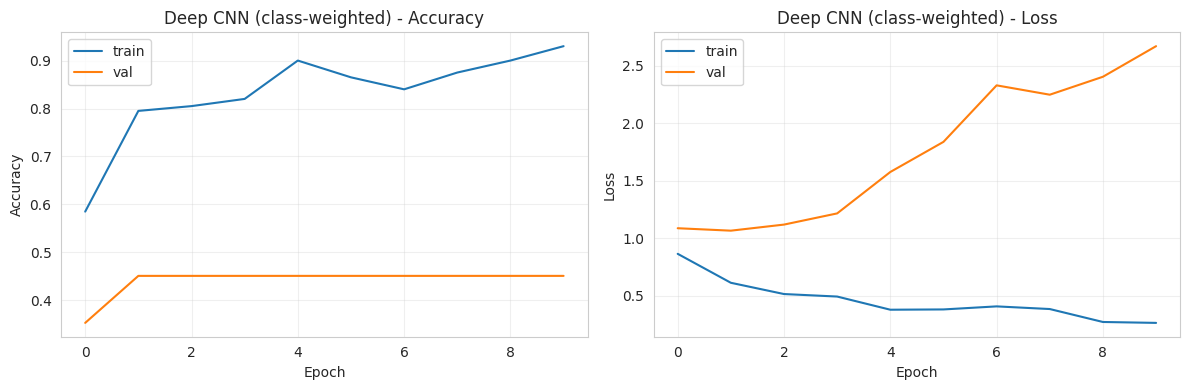


------ Deep CNN (weighted) ------
Test accuracy   : 0.3939
Macro F1        : 0.1884
Macro ROC-AUC   : 0.5259
Train acc (best): 0.9300   Val acc (best): 0.4510   Gap: +0.4790   Overfitting: Y
Trainable params: 110,595

Classification report:
                 precision    recall  f1-score   support

          Covid       0.39      1.00      0.57        26
         Normal       0.00      0.00      0.00        20
Viral Pneumonia       0.00      0.00      0.00        20

       accuracy                           0.39        66
      macro avg       0.13      0.33      0.19        66
   weighted avg       0.16      0.39      0.22        66



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


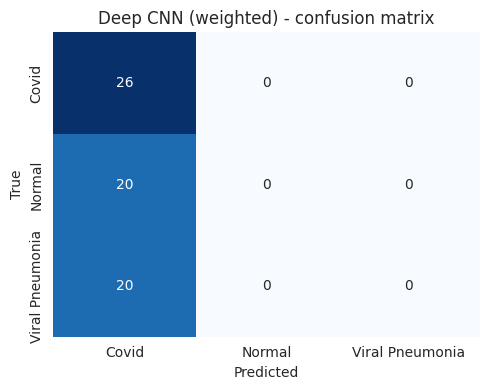

In [18]:
deep_cnn_weighted = build_deep_cnn()
hist_deep_w = deep_cnn_weighted.fit(
    X_train, y_train_oh,
    validation_data=(X_val, y_val_oh),
    epochs=35,
    batch_size=16,
    class_weight=class_weights,
    callbacks=get_callbacks("deep_cnn_weighted"),
    verbose=2,
)
plot_history(hist_deep_w, "Deep CNN (class-weighted)")
results.append(evaluate_model(
    deep_cnn_weighted, X_test, y_test_oh, y_test_enc, hist_deep_w,
    "Deep CNN (weighted)"
))

## 7. Model Tuning with Keras Tuner

We run a small **Hyperband** search over the Deep CNN architecture: number of conv filters in each block, dropout rate, dense units, and learning rate.

In [21]:
import keras_tuner as kt

def build_tunable_cnn(hp):
    f1 = hp.Choice("filters_1", [16, 32, 64])
    f2 = hp.Choice("filters_2", [32, 64, 128])
    f3 = hp.Choice("filters_3", [64, 128, 256])
    dropout = hp.Float("dropout", 0.2, 0.6, step=0.1)
    units   = hp.Choice("dense_units", [64, 128, 256])
    lr      = hp.Choice("lr", [1e-3, 5e-4, 1e-4])

    model = models.Sequential([
        layers.Input(shape=INPUT_SHAPE),
        layers.Conv2D(f1, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2),
        layers.Conv2D(f2, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2),
        layers.Conv2D(f3, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2),
        layers.GlobalAveragePooling2D(),
        layers.Dense(units, activation="relu"),
        layers.Dropout(dropout),
        layers.Dense(NUM_CLASSES, activation="softmax"),
    ])
    model.compile(optimizer=optimizers.Adam(lr),
                  loss="categorical_crossentropy",
                  metrics=["accuracy"])
    return model

tuner = kt.Hyperband(
    build_tunable_cnn,
    objective="val_accuracy",
    max_epochs=15,
    factor=3,
    directory=os.path.join(MODELS_DIR, "kt"),
    project_name="covid_cnn",
    overwrite=True,
)
print("Tuner search space:")
tuner.search_space_summary()

Tuner search space:
Search space summary
Default search space size: 6
filters_1 (Choice)
{'default': 16, 'conditions': [], 'values': [16, 32, 64], 'ordered': True}
filters_2 (Choice)
{'default': 32, 'conditions': [], 'values': [32, 64, 128], 'ordered': True}
filters_3 (Choice)
{'default': 64, 'conditions': [], 'values': [64, 128, 256], 'ordered': True}
dropout (Float)
{'default': 0.2, 'conditions': [], 'min_value': 0.2, 'max_value': 0.6, 'step': 0.1, 'sampling': 'linear'}
dense_units (Choice)
{'default': 64, 'conditions': [], 'values': [64, 128, 256], 'ordered': True}
lr (Choice)
{'default': 0.001, 'conditions': [], 'values': [0.001, 0.0005, 0.0001], 'ordered': True}


In [22]:
tuner.search(
    X_train, y_train_oh,
    validation_data=(X_val, y_val_oh),
    epochs=15,
    batch_size=16,
    callbacks=[callbacks.EarlyStopping(patience=4, restore_best_weights=True)],
    class_weight=class_weights,
    verbose=2,
)

best_hp = tuner.get_best_hyperparameters(1)[0]
print("\nBest hyperparameters found:")
for k in best_hp.values:
    print(f"  {k}: {best_hp.values[k]}")

Trial 30 Complete [00h 02m 42s]
val_accuracy: 0.45098039507865906

Best val_accuracy So Far: 0.4901960790157318
Total elapsed time: 00h 38m 22s

Best hyperparameters found:
  filters_1: 32
  filters_2: 64
  filters_3: 128
  dropout: 0.4
  dense_units: 256
  lr: 0.001
  tuner/epochs: 2
  tuner/initial_epoch: 0
  tuner/bracket: 2
  tuner/round: 0


Epoch 1/40
13/13 - 16s - 1s/step - accuracy: 0.5850 - loss: 0.8846 - val_accuracy: 0.4510 - val_loss: 1.0804 - learning_rate: 0.0010
Epoch 2/40
13/13 - 19s - 1s/step - accuracy: 0.7700 - loss: 0.5877 - val_accuracy: 0.4510 - val_loss: 1.0679 - learning_rate: 0.0010
Epoch 3/40
13/13 - 22s - 2s/step - accuracy: 0.7900 - loss: 0.5641 - val_accuracy: 0.4510 - val_loss: 1.0800 - learning_rate: 0.0010
Epoch 4/40
13/13 - 19s - 1s/step - accuracy: 0.8400 - loss: 0.4495 - val_accuracy: 0.4510 - val_loss: 1.1818 - learning_rate: 0.0010
Epoch 5/40

Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
13/13 - 13s - 977ms/step - accuracy: 0.8700 - loss: 0.3457 - val_accuracy: 0.4510 - val_loss: 1.3371 - learning_rate: 0.0010
Epoch 6/40
13/13 - 19s - 1s/step - accuracy: 0.8550 - loss: 0.3765 - val_accuracy: 0.4510 - val_loss: 1.5692 - learning_rate: 5.0000e-04
Epoch 7/40
13/13 - 12s - 920ms/step - accuracy: 0.9200 - loss: 0.2425 - val_accuracy: 0.4510 - val_loss: 1.9076 - lear

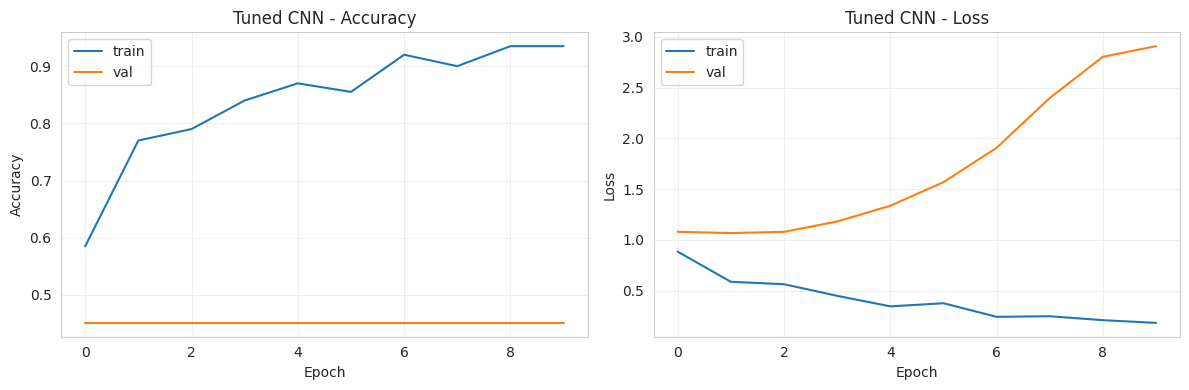


------ Tuned CNN (Keras Tuner) ------
Test accuracy   : 0.3939
Macro F1        : 0.1884
Macro ROC-AUC   : 0.4940
Train acc (best): 0.9350   Val acc (best): 0.4510   Gap: +0.4840   Overfitting: Y
Trainable params: 127,491

Classification report:
                 precision    recall  f1-score   support

          Covid       0.39      1.00      0.57        26
         Normal       0.00      0.00      0.00        20
Viral Pneumonia       0.00      0.00      0.00        20

       accuracy                           0.39        66
      macro avg       0.13      0.33      0.19        66
   weighted avg       0.16      0.39      0.22        66



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


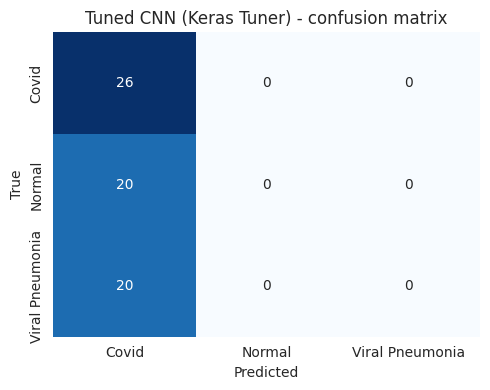

In [23]:
# Train the best-tuned model for more epochs, evaluate on test
tuned_cnn = tuner.hypermodel.build(best_hp)
hist_tuned = tuned_cnn.fit(
    X_train, y_train_oh,
    validation_data=(X_val, y_val_oh),
    epochs=40,
    batch_size=16,
    class_weight=class_weights,
    callbacks=get_callbacks("tuned_cnn"),
    verbose=2,
)
plot_history(hist_tuned, "Tuned CNN")
results.append(evaluate_model(
    tuned_cnn, X_test, y_test_oh, y_test_enc, hist_tuned,
    "Tuned CNN (Keras Tuner)"
))

## 8. Model Comparison Table

In [32]:
comparison_df = pd.DataFrame(results)[
    ["model", "train_acc", "test_acc", "f1_macro", "roc_auc", "overfitting", "trainable"]
].rename(columns={
    "model":       "Model",
    "train_acc":   "Train Acc",
    "test_acc":    "Test Acc",
    "f1_macro":    "F1 Score",
    "roc_auc":     "ROC-AUC",
    "overfitting": "Overfitting (Y/N)",
    "trainable":   "Trainable Params",
})

# Append "Best Model" row
best_idx = comparison_df["F1 Score"].idxmax()
best_row = comparison_df.loc[best_idx].copy()
best_row["Model"] = f"** Best: {best_row['Model']}"
comparison_df = pd.concat([comparison_df, best_row.to_frame().T], ignore_index=True)

comparison_df

,Model,Train Acc,Test Acc,F1 Score,ROC-AUC,Overfitting (Y/N),Trainable Params
0,Basic CNN,1.0,0.8485,0.8375,0.9604,N,8129667
1,Deep CNN,0.92,0.3939,0.1884,0.5864,Y,110595
2,VGG16,1.0,0.9242,0.9153,1.0,N,7145475
3,ResNet50 + Aug,1.0,0.8182,0.8131,0.9428,N,4728323
4,Deep CNN (weighted),0.93,0.3939,0.1884,0.5259,Y,110595
5,Tuned CNN (Keras Tuner),0.935,0.3939,0.1884,0.494,Y,127491
6,** Best: VGG16,1.0,0.9242,0.9153,1.0,N,7145475


In [33]:
import os
import json

# Save the best model so the Streamlit app can load it
best_model_name = comparison_df.loc[best_idx, "Model"]
name_to_model = {
    "Basic CNN":               (basic_cnn,         "rgb_norm"),
    "Deep CNN":                (deep_cnn,          "rgb_norm"),
    "VGG16":                   (vgg_model,         "vgg"),
    "ResNet50 + Aug":          (resnet_model,      "resnet"),
    "Deep CNN (weighted)":     (deep_cnn_weighted, "rgb_norm"),
    "Tuned CNN (Keras Tuner)": (tuned_cnn,         "rgb_norm"),
}
best_model_obj, best_preprocess = name_to_model[best_model_name]

# Create a local "models" folder in the current working directory
LOCAL_MODELS_DIR = os.path.join(os.getcwd(), "models")
os.makedirs(LOCAL_MODELS_DIR, exist_ok=True)

# Save the model locally
best_path = os.path.join(LOCAL_MODELS_DIR, "best_model.keras")
best_model_obj.save(best_path)

# Save a small metadata file so the Streamlit app knows how to preprocess
img_size_used = int(X_train.shape[1])
meta = {
    "model_name":   best_model_name,
    "img_size":     img_size_used,
    "classes":      list(CLASSES),
    "preprocess":   best_preprocess,   # "rgb_norm" | "vgg" | "resnet"
}
meta_path = os.path.join(LOCAL_MODELS_DIR, "best_model_meta.json")
with open(meta_path, "w") as f:
    json.dump(meta, f, indent=2)

print(f"Saved best model: {best_model_name} -> {best_path}")
print(f"   Metadata saved to: {meta_path}")
print(f"   Metadata content: {meta}")

Saved best model: VGG16 -> /content/models/best_model.keras
   Metadata saved to: /content/models/best_model_meta.json
   Metadata content: {'model_name': 'VGG16', 'img_size': 128, 'classes': [np.str_('Covid'), np.str_('Normal'), np.str_('Viral Pneumonia')], 'preprocess': 'vgg'}


In [36]:
from google.colab import drive
drive.mount('/content/drive')

import shutil
shutil.copy(best_path, '/content/drive/MyDrive/Data_Science/CNN_MINI/best_model.keras')
shutil.copy(meta_path, '/content/drive/MyDrive/Data_Science/CNN_MINI/best_model_meta.json')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


'/content/drive/MyDrive/Data_Science/CNN_MINI/best_model_meta.json'